# HumAID Disaster Tweet Classification: Word2Vec & Recurrent Deep Learning Benchmark

This notebook implements an end-to-end, decoupled 2-stage hyperparameter tuning and deep learning evaluation pipeline for disaster tweet classification:

1. **Stage 1: Word2Vec Feature Representation Sweep**
   - Evaluates multiple **CBOW & Skip-Gram** representations using a standardized baseline probe BiLSTM ($L=48, H=128$).
   - Determines the optimal semantic embedding space for disaster crisis terminology.
   
2. **Stage 2: Recurrent Architecture Hyperparameter Grids**
   - Models Evaluated: **BiRNN**, **BiLSTM**, **BiGRU**, **2-Stacked BiLSTM**
   - Evaluates sequence length $L \in \{32, 48, 64\}$ and hidden dimension $H \in \{64, 128, 256\}$.

3. **Evaluation & Artifact Generation**
   - Validation 2D heatmaps and tuning curves for every model.
   - Dual confusion matrices (Counts and Normalized % with formatted human class names, 35° rotation, 300 DPI).
   - Per-class metric bar charts, training convergence curves, and classification reports.
   - Master benchmark summary table and cross-architecture comparison plots.


In [1]:
import os
import gc
import re
import time
import glob
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Any

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Compute Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")


Using Compute Device: cuda
GPU Name: Tesla T4
Memory Allocated: 0.00 MB


In [2]:
# Robust Data Path Resolution (Local, Kaggle Input, Google Drive Fallback)
def find_data_file(filename):
    search_patterns = [
        f"/kaggle/input/**/{filename}",
        f"dataset/{filename}",
        f"d:/nlp-project/dataset/{filename}",
        f"../dataset/{filename}",
        f"**/{filename}"
    ]
    for pattern in search_patterns:
        matches = glob.glob(pattern, recursive=True)
        if matches:
            return matches[0]
    return None

train_file = find_data_file("train_clean.parquet") or find_data_file("train.parquet")
val_file = find_data_file("validation_clean.parquet") or find_data_file("validation.parquet")
test_file = find_data_file("test_clean.parquet") or find_data_file("test.parquet")

if train_file is None or val_file is None or test_file is None:
    print("[!] Parquet files not found locally, downloading from Google Drive...")
    import gdown
    os.makedirs("dataset", exist_ok=True)
    GDRIVE_URL = "https://drive.google.com/drive/folders/1pyMBc4SFc-sQvfmReiywPoN5cQbMpQBR?usp=drive_link"
    gdown.download_folder(url=GDRIVE_URL, output="dataset", quiet=False, use_cookies=False)
    train_file = find_data_file("train_clean.parquet") or find_data_file("train.parquet")
    val_file = find_data_file("validation_clean.parquet") or find_data_file("validation.parquet")
    test_file = find_data_file("test_clean.parquet") or find_data_file("test.parquet")

print(f"Found Train File: {train_file}")
print(f"Found Val File:   {val_file}")
print(f"Found Test File:  {test_file}")

# Output directory structure
OUTPUT_BASE = "results/02_word2vec_recurrent_models"
if not os.path.exists("results") and os.path.exists("/kaggle/working"):
    OUTPUT_BASE = "/kaggle/working/results/02_word2vec_recurrent_models"

MODEL_DIRS = {
    "embedding": os.path.join(OUTPUT_BASE, "word2vec"),
    "birnn": os.path.join(OUTPUT_BASE, "models", "birnn"),
    "bilstm": os.path.join(OUTPUT_BASE, "models", "bilstm"),
    "bigru": os.path.join(OUTPUT_BASE, "models", "bigru"),
    "stacked_bilstm": os.path.join(OUTPUT_BASE, "models", "stacked_bilstm"),
    "summary": os.path.join(OUTPUT_BASE, "summary")
}

for d in MODEL_DIRS.values():
    os.makedirs(d, exist_ok=True)

print(f"Output directory initialized at: {OUTPUT_BASE}")


Found Train File: /kaggle/input/datasets/nayeem898/humaid-disaster-tweets-parquet/train.parquet
Found Val File:   /kaggle/input/datasets/nayeem898/humaid-disaster-tweets-parquet/validation.parquet
Found Test File:  /kaggle/input/datasets/nayeem898/humaid-disaster-tweets-parquet/test.parquet
Output directory initialized at: /kaggle/working/results/02_word2vec_recurrent_models


In [3]:
# Load datasets
train_df = pd.read_parquet(train_file)
val_df = pd.read_parquet(val_file)
test_df = pd.read_parquet(test_file)

text_col = 'clean_text' if 'clean_text' in train_df.columns else ('text' if 'text' in train_df.columns else train_df.columns[0])
label_col = 'label' if 'label' in train_df.columns else ('class_label' if 'class_label' in train_df.columns else train_df.columns[1])

print(f"Dataset Loaded:")
print(f"  Train:      {len(train_df):,} samples")
print(f"  Validation: {len(val_df):,} samples")
print(f"  Test:       {len(test_df):,} samples")

# Class label mapping & formatted human names
raw_labels = sorted(train_df[label_col].unique().tolist())
label2id = {lbl: i for i, lbl in enumerate(raw_labels)}
id2label = {i: lbl for lbl, i in label2id.items()}
num_classes = len(raw_labels)

def format_label(name):
    return ' '.join(word.capitalize() for word in str(name).replace('_', ' ').split())

formatted_class_names = [format_label(id2label[i]) for i in range(num_classes)]

print(f"\nDisaster Classes ({num_classes}):")
for i, name in enumerate(formatted_class_names):
    print(f"  [{i}] {raw_labels[i]} -> {name}")

def simple_tokenize(text):
    if not isinstance(text, str):
        return []
    return text.lower().strip().split()

train_tokens = [simple_tokenize(t) for t in train_df[text_col]]
val_tokens = [simple_tokenize(t) for t in val_df[text_col]]
test_tokens = [simple_tokenize(t) for t in test_df[text_col]]

y_train = np.array([label2id[l] for l in train_df[label_col]], dtype=np.int64)
y_val = np.array([label2id[l] for l in val_df[label_col]], dtype=np.int64)
y_test = np.array([label2id[l] for l in test_df[label_col]], dtype=np.int64)


Dataset Loaded:
  Train:      53,531 samples
  Validation: 7,793 samples
  Test:       15,160 samples

Disaster Classes (10):
  [0] caution_and_advice -> Caution And Advice
  [1] displaced_people_and_evacuations -> Displaced People And Evacuations
  [2] infrastructure_and_utility_damage -> Infrastructure And Utility Damage
  [3] injured_or_dead_people -> Injured Or Dead People
  [4] missing_or_found_people -> Missing Or Found People
  [5] not_humanitarian -> Not Humanitarian
  [6] other_relevant_information -> Other Relevant Information
  [7] requests_or_urgent_needs -> Requests Or Urgent Needs
  [8] rescue_volunteering_or_donation_effort -> Rescue Volunteering Or Donation Effort
  [9] sympathy_and_support -> Sympathy And Support


## Stage 1: Word2Vec Feature Representation Tuning

We evaluate candidate Word2Vec configurations on a standardized baseline probe model (`BiLSTM`, $L=48, H=128$, 1 layer, Adam $\text{lr}=10^{-3}$, batch size $64$).

This isolates the feature representation quality before performing model architecture tuning.


In [4]:
# PyTorch Dataset for Recurrent Models
class TweetSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

def numericalize_tokens(token_list, vocab, max_len):
    padded_seqs = np.zeros((len(token_list), max_len), dtype=np.int64)
    for i, tokens in enumerate(token_list):
        for j, word in enumerate(tokens[:max_len]):
            padded_seqs[i, j] = vocab.get(word, 1) # 1 is <UNK>
    return padded_seqs

class ProbeBiLSTM(nn.Module):
    def __init__(self, embed_matrix, hidden_dim=128, num_classes=10, dropout=0.3):
        super(ProbeBiLSTM, self).__init__()
        num_embeddings, embed_dim = embed_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embed_matrix, dtype=torch.float32),
            freeze=False,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        pooled = torch.max(out, dim=1)[0]
        pooled = self.dropout(pooled)
        logits = self.fc(pooled)
        return logits

def train_and_eval_probe(model, train_loader, val_loader, epochs=5, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()
    best_val_f1 = 0.0
    best_val_acc = 0.0
    
    model.to(device)
    for epoch in range(epochs):
        model.train()
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(x_b)
            loss = criterion(logits, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b = x_b.to(device)
                logits = model(x_b)
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                targets.extend(y_b.numpy())
                
        val_acc = accuracy_score(targets, preds)
        _, _, val_f1, _ = precision_recall_fscore_support(targets, preds, average='macro', zero_division=0)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            
    return best_val_f1, best_val_acc


In [5]:
# Stage 1: Word2Vec Hyperparameter Configurations
from gensim.models import Word2Vec

def build_vocab_and_matrix_w2v(w2v_model, embed_dim):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    vectors = [np.zeros(embed_dim, dtype=np.float32), np.random.uniform(-0.1, 0.1, embed_dim).astype(np.float32)]
    for word in w2v_model.wv.index_to_key:
        vocab[word] = len(vocab)
        vectors.append(w2v_model.wv[word])
    return vocab, np.array(vectors, dtype=np.float32)

configs = [
    {"name": "CBOW_100d_w5", "sg": 0, "dim": 100, "window": 5},
    {"name": "CBOW_300d_w5", "sg": 0, "dim": 300, "window": 5},
    {"name": "SkipGram_100d_w5", "sg": 1, "dim": 100, "window": 5},
    {"name": "SkipGram_300d_w3", "sg": 1, "dim": 300, "window": 3},
    {"name": "SkipGram_300d_w5", "sg": 1, "dim": 300, "window": 5},
]

stage1_results = []
trained_models = {}
vocab_matrices = {}

print("="*75)
print("STAGE 1: Word2Vec Hyperparameter Sweep (Probe BiLSTM, L=48, H=128)")
print("="*75)

for cfg in configs:
    t0 = time.time()
    print(f"\n--> Training Word2Vec: {cfg['name']} (sg={cfg['sg']}, dim={cfg['dim']}, win={cfg['window']})...")
    w2v = Word2Vec(
        sentences=train_tokens, vector_size=cfg['dim'], window=cfg['window'],
        sg=cfg['sg'], min_count=2, workers=4, epochs=10, seed=42
    )
    vocab, embed_matrix = build_vocab_and_matrix_w2v(w2v, cfg['dim'])
    trained_models[cfg['name']] = w2v
    vocab_matrices[cfg['name']] = (vocab, embed_matrix)
    
    X_train_probe = numericalize_tokens(train_tokens, vocab, max_len=48)
    X_val_probe = numericalize_tokens(val_tokens, vocab, max_len=48)
    
    train_loader_probe = DataLoader(TweetSequenceDataset(X_train_probe, y_train), batch_size=64, shuffle=True)
    val_loader_probe = DataLoader(TweetSequenceDataset(X_val_probe, y_val), batch_size=128, shuffle=False)
    
    set_seed(42)
    probe_model = ProbeBiLSTM(embed_matrix, hidden_dim=128, num_classes=num_classes, dropout=0.3)
    val_f1, val_acc = train_and_eval_probe(probe_model, train_loader_probe, val_loader_probe, epochs=5, lr=1e-3)
    total_time = time.time() - t0
    
    print(f"    Validation Macro F1: {val_f1:.4f} | Accuracy: {val_acc:.4f} | Time: {total_time:.1f}s")
    stage1_results.append({
        "Config": cfg['name'], "Architecture": "Skip-Gram" if cfg['sg'] == 1 else "CBOW",
        "Dimension": cfg['dim'], "Window": cfg['window'], "Val_Macro_F1": round(val_f1, 4),
        "Val_Accuracy": round(val_acc, 4), "Vocab_Size": len(vocab), "Time_Sec": round(total_time, 2)
    })

df_stage1 = pd.DataFrame(stage1_results).sort_values(by="Val_Macro_F1", ascending=False)
df_stage1.to_csv(os.path.join(MODEL_DIRS["embedding"], "word2vec_tuning_summary.csv"), index=False)
print("\n" + "="*75)
print("STAGE 1 SUMMARY: Word2Vec Hyperparameter Ranking")
print("="*75)
print(df_stage1.to_string(index=False))

best_emb_name = df_stage1.iloc[0]["Config"]
BEST_VOCAB, BEST_EMBED_MATRIX = vocab_matrices[best_emb_name]
BEST_EMBED_DIM = BEST_EMBED_MATRIX.shape[1]
trained_models[best_emb_name].save(os.path.join(MODEL_DIRS["embedding"], "best_word2vec.model"))
with open(os.path.join(MODEL_DIRS["embedding"], "vocab2id.json"), "w") as f:
    json.dump(BEST_VOCAB, f)
print(f"\n>> Selected Best Word2Vec Embedding: {best_emb_name} (Dimension={BEST_EMBED_DIM}, Vocab={len(BEST_VOCAB)})")


STAGE 1: Word2Vec Hyperparameter Sweep (Probe BiLSTM, L=48, H=128)

--> Training Word2Vec: CBOW_100d_w5 (sg=0, dim=100, win=5)...
    Validation Macro F1: 0.7110 | Accuracy: 0.7458 | Time: 35.7s

--> Training Word2Vec: CBOW_300d_w5 (sg=0, dim=300, win=5)...
    Validation Macro F1: 0.7241 | Accuracy: 0.7431 | Time: 50.8s

--> Training Word2Vec: SkipGram_100d_w5 (sg=1, dim=100, win=5)...
    Validation Macro F1: 0.7216 | Accuracy: 0.7518 | Time: 48.7s

--> Training Word2Vec: SkipGram_300d_w3 (sg=1, dim=300, win=3)...
    Validation Macro F1: 0.7232 | Accuracy: 0.7534 | Time: 67.1s

--> Training Word2Vec: SkipGram_300d_w5 (sg=1, dim=300, win=5)...
    Validation Macro F1: 0.7241 | Accuracy: 0.7563 | Time: 78.0s

STAGE 1 SUMMARY: Word2Vec Hyperparameter Ranking
          Config Architecture  Dimension  Window  Val_Macro_F1  Val_Accuracy  Vocab_Size  Time_Sec
    CBOW_300d_w5         CBOW        300       5        0.7241        0.7431       33718     50.77
SkipGram_300d_w5    Skip-Gram    

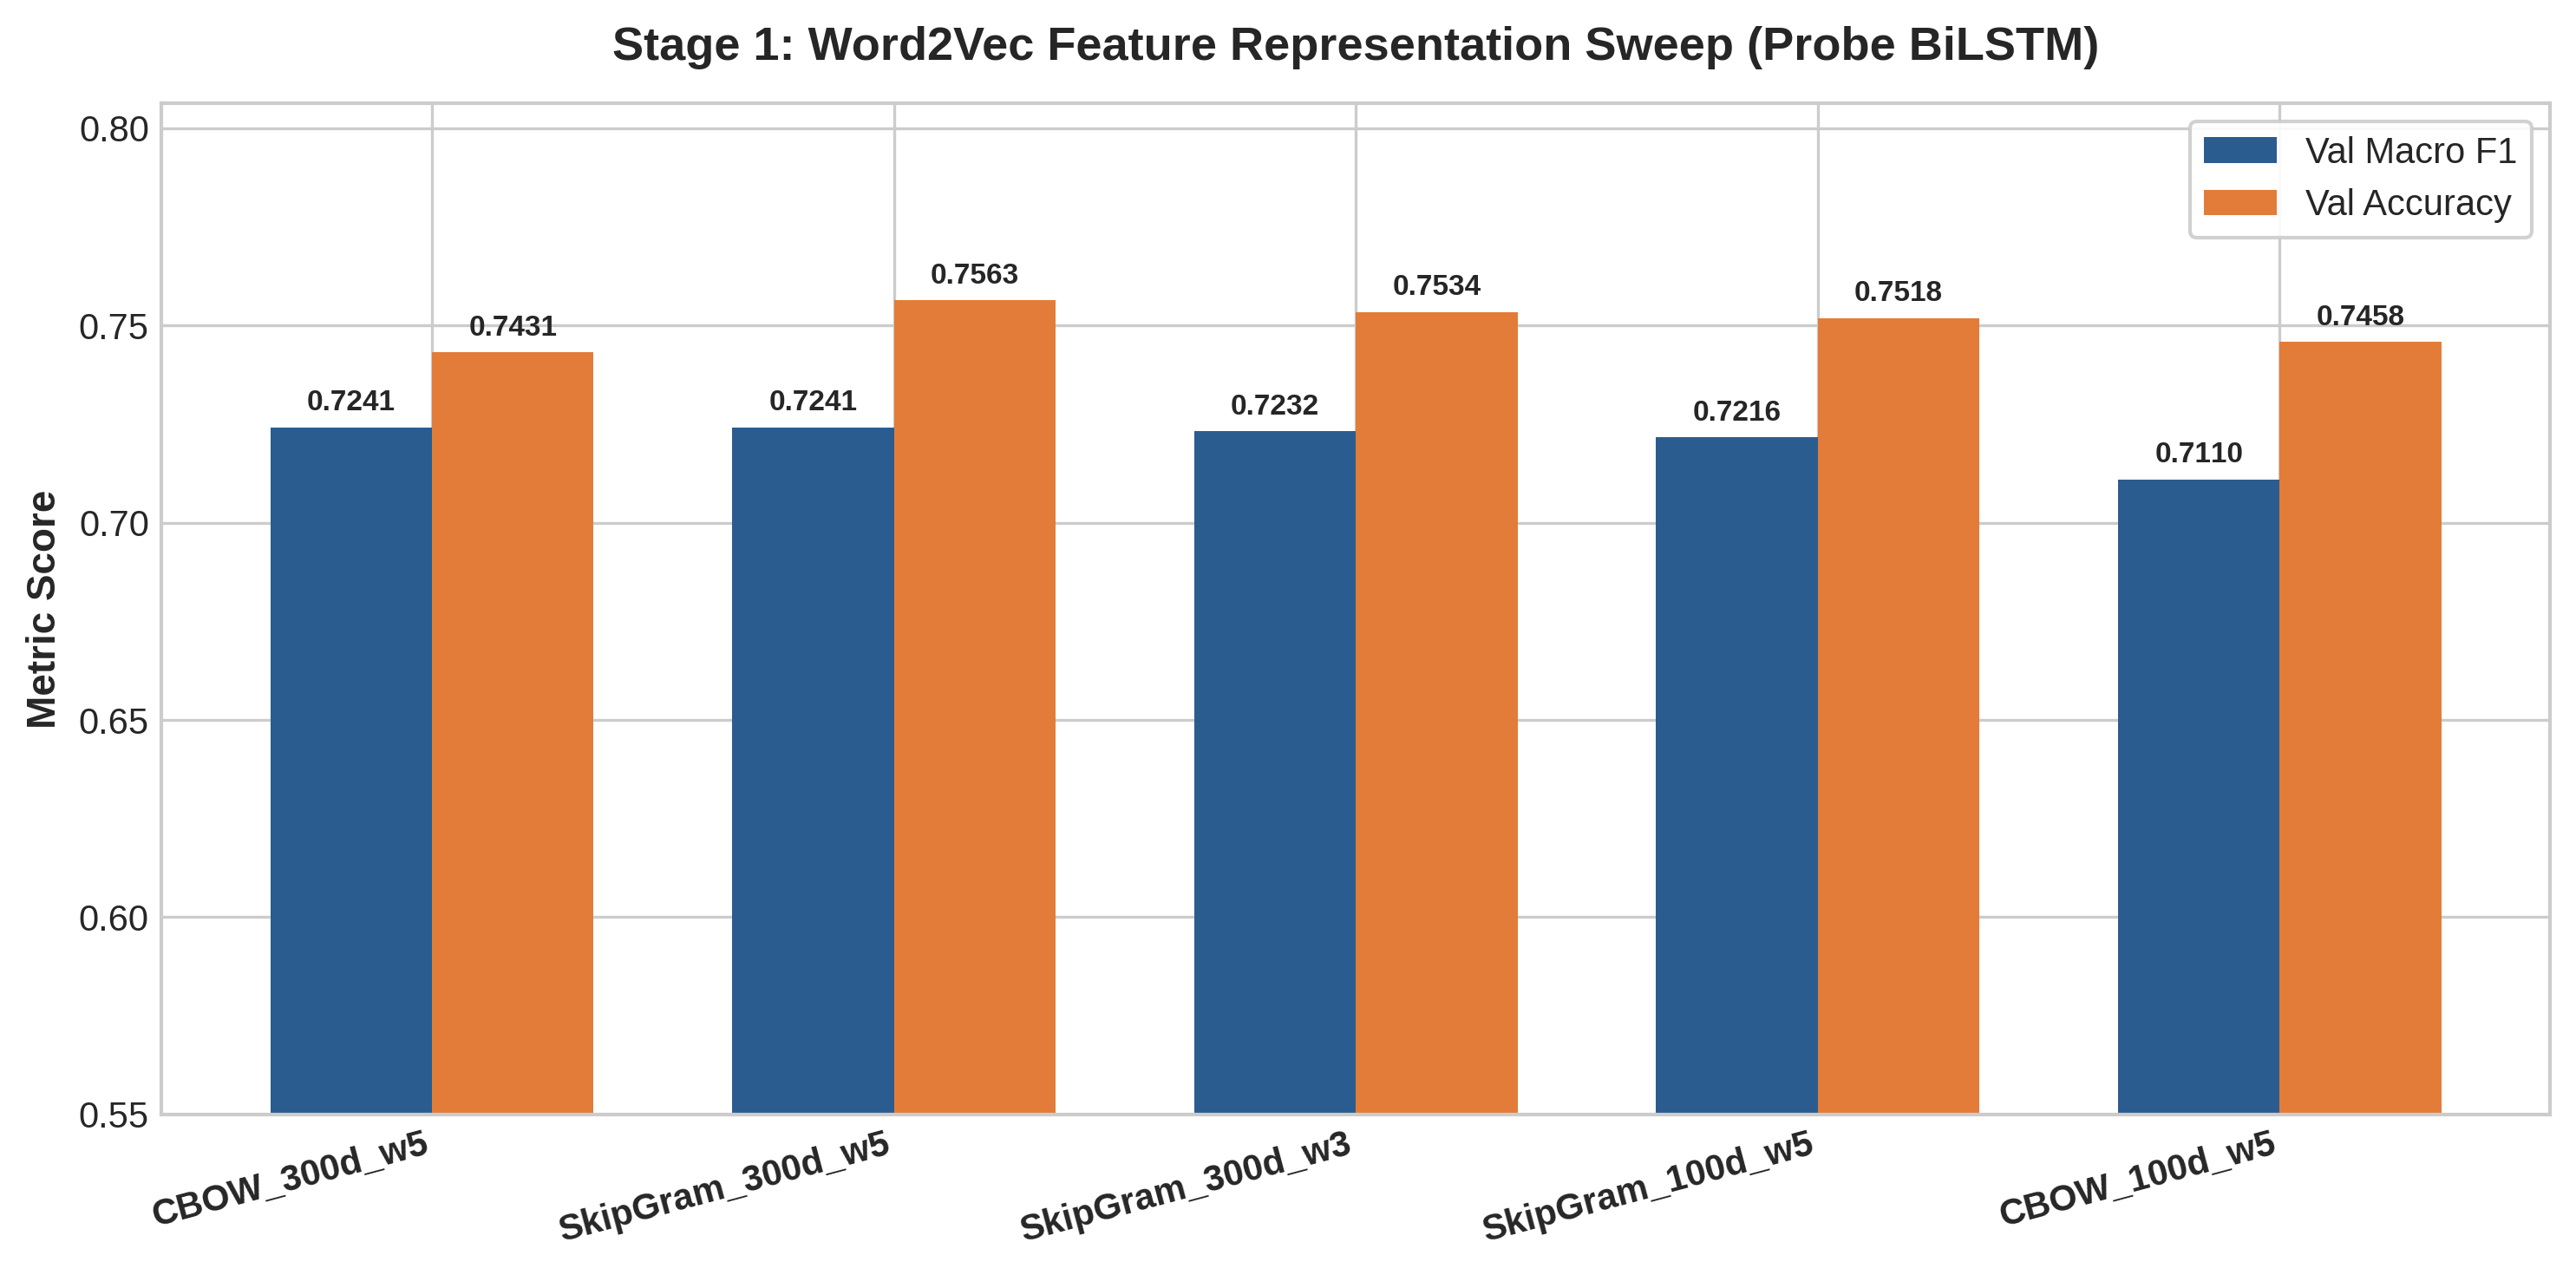

In [6]:
# Stage 1 Plot: Word2Vec Tuning Comparison
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

x = np.arange(len(df_stage1))
width = 0.35

rects1 = ax.bar(x - width/2, df_stage1["Val_Macro_F1"], width, label="Val Macro F1", color="#2b5c8f")
rects2 = ax.bar(x + width/2, df_stage1["Val_Accuracy"], width, label="Val Accuracy", color="#e27c38")

ax.set_title("Stage 1: Word2Vec Feature Representation Sweep (Probe BiLSTM)", fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel("Metric Score", fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_stage1["Config"], rotation=15, ha='right', fontsize=10, fontweight='bold')
ax.set_ylim(0.55, max(df_stage1["Val_Accuracy"].max(), df_stage1["Val_Macro_F1"].max()) + 0.05)
ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10)

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f"{h:.4f}", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax.annotate(f"{h:.4f}", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIRS["embedding"], "word2vec_hyperparam_comparison.png"), dpi=300)
plt.show()


## Stage 2: Recurrent Neural Network Architectures (BiRNN, BiLSTM, BiGRU, 2-Stacked BiLSTM)

Using the best Word2Vec feature representation $W^*$, we now tune the model architectures:
- Sequence Length $L \in \{32, 48, 64\}$
- Hidden Dimension $H \in \{64, 128, 256\}$


In [7]:
class RecurrentClassifier(nn.Module):
    def __init__(self, cell_type: str, embed_matrix: np.ndarray, hidden_dim: int = 128, 
                 num_layers: int = 1, dropout: float = 0.3, num_classes: int = 10):
        super(RecurrentClassifier, self).__init__()
        self.cell_type = cell_type.lower()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        
        num_embeddings, embed_dim = embed_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embed_matrix, dtype=torch.float32),
            freeze=False,
            padding_idx=0
        )
        
        rnn_dropout = dropout if num_layers > 1 else 0.0
        
        if self.cell_type == 'rnn':
            self.rnn = nn.RNN(
                embed_dim, hidden_dim, num_layers=num_layers,
                batch_first=True, bidirectional=True, nonlinearity='tanh', dropout=rnn_dropout
            )
        elif self.cell_type == 'lstm':
            self.rnn = nn.LSTM(
                embed_dim, hidden_dim, num_layers=num_layers,
                batch_first=True, bidirectional=True, dropout=rnn_dropout
            )
        elif self.cell_type == 'gru':
            self.rnn = nn.GRU(
                embed_dim, hidden_dim, num_layers=num_layers,
                batch_first=True, bidirectional=True, dropout=rnn_dropout
            )
        else:
            raise ValueError(f"Unknown cell_type: {cell_type}")
            
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        pooled = torch.max(out, dim=1)[0]
        pooled = self.dropout(pooled)
        logits = self.fc(pooled)
        return logits

PRECOMPUTED_DATA = {}
for L in [32, 48, 64]:
    PRECOMPUTED_DATA[L] = {
        "train": numericalize_tokens(train_tokens, BEST_VOCAB, max_len=L),
        "val": numericalize_tokens(val_tokens, BEST_VOCAB, max_len=L),
        "test": numericalize_tokens(test_tokens, BEST_VOCAB, max_len=L)
    }
print("Precomputed token sequences for L in [32, 48, 64] successfully.")


Precomputed token sequences for L in [32, 48, 64] successfully.


In [8]:
def train_recurrent_model(model, train_loader, val_loader, max_epochs=8, lr=1e-3, patience=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()
    best_val_f1 = 0.0
    best_state = None
    best_epoch = 0
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    patience_counter = 0
    model.to(device)
    
    for epoch in range(1, max_epochs + 1):
        model.train()
        total_train_loss = 0.0
        train_preds, train_targets = [], []
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(x_b)
            loss = criterion(logits, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_train_loss += loss.item() * len(y_b)
            train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            train_targets.extend(y_b.detach().cpu().numpy())
            
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        _, _, train_f1, _ = precision_recall_fscore_support(train_targets, train_preds, average='macro', zero_division=0)
        
        model.eval()
        total_val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                logits = model(x_b)
                loss = criterion(logits, y_b)
                total_val_loss += loss.item() * len(y_b)
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_targets.extend(y_b.cpu().numpy())
                
        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_acc = accuracy_score(val_targets, val_preds)
        _, _, val_f1, _ = precision_recall_fscore_support(val_targets, val_preds, average='macro', zero_division=0)
        
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
                
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val_f1, best_epoch, history

def evaluate_model_on_test(model, test_loader, y_true, model_name, save_dir, history=None):
    model.eval()
    model.to(device)
    preds = []
    t0 = time.time()
    with torch.no_grad():
        for x_b, _ in test_loader:
            x_b = x_b.to(device)
            logits = model(x_b)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
    latency_ms = ((time.time() - t0) / len(y_true)) * 1000.0
    preds = np.array(preds)
    
    acc = accuracy_score(y_true, preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, preds, average='macro', zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, preds, average='weighted', zero_division=0)
    
    cls_dict = classification_report(y_true, preds, target_names=formatted_class_names, output_dict=True, zero_division=0)
    df_cls = pd.DataFrame(cls_dict).transpose()
    df_cls.to_csv(os.path.join(save_dir, "classification_report.csv"))
    with open(os.path.join(save_dir, "classification_report.txt"), "w") as f:
        f.write(classification_report(y_true, preds, target_names=formatted_class_names, digits=4, zero_division=0))
        
    cm_raw = confusion_matrix(y_true, preds)
    cm_norm = confusion_matrix(y_true, preds, normalize='true') * 100.0
    annot_matrix = np.empty_like(cm_raw, dtype=object)
    for i in range(num_classes):
        for j in range(num_classes):
            annot_matrix[i, j] = f"{cm_raw[i, j]}\n({cm_norm[i, j]:.1f}%)"
            
    plt.figure(figsize=(12, 10), dpi=300)
    sns.heatmap(cm_norm, annot=annot_matrix, fmt="", cmap="Blues", cbar=True,
                xticklabels=formatted_class_names, yticklabels=formatted_class_names,
                annot_kws={"size": 8, "fontweight": "bold"})
    plt.title(f"Confusion Matrix: {model_name} (Counts & Normalized %)", fontsize=13, fontweight='bold', pad=14)
    plt.xlabel("Predicted Disaster Class", fontsize=11, fontweight='bold')
    plt.ylabel("True Disaster Class", fontsize=11, fontweight='bold')
    plt.xticks(rotation=35, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=300)
    plt.close()
    
    per_class_f1 = [cls_dict[c]["f1-score"] for c in formatted_class_names]
    per_class_rec = [cls_dict[c]["recall"] for c in formatted_class_names]
    per_class_prec = [cls_dict[c]["precision"] for c in formatted_class_names]
    
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    x = np.arange(num_classes)
    w = 0.25
    ax.bar(x - w, per_class_prec, w, label="Precision", color="#3498db")
    ax.bar(x, per_class_rec, w, label="Recall", color="#2ecc71")
    ax.bar(x + w, per_class_f1, w, label="F1-Score", color="#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels(formatted_class_names, rotation=35, ha='right', fontsize=9, fontweight='bold')
    ax.set_ylabel("Score", fontsize=11, fontweight='bold')
    ax.set_title(f"Per-Class Performance: {model_name}", fontsize=13, fontweight='bold', pad=12)
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "per_class_metrics.png"), dpi=300)
    plt.close()
    
    if history is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=300)
        epochs = range(1, len(history["train_loss"]) + 1)
        ax1.plot(epochs, history["train_loss"], 'o-', label="Train Loss", color="#2980b9", lw=2)
        ax1.plot(epochs, history["val_loss"], 's--', label="Val Loss", color="#c0392b", lw=2)
        ax1.set_title(f"Loss Curves: {model_name}", fontsize=11, fontweight='bold')
        ax1.set_xlabel("Epoch", fontweight='bold')
        ax1.set_ylabel("Cross Entropy Loss", fontweight='bold')
        ax1.legend()
        
        ax2.plot(epochs, history["train_f1"], 'o-', label="Train Macro F1", color="#27ae60", lw=2)
        ax2.plot(epochs, history["val_f1"], 's--', label="Val Macro F1", color="#8e44ad", lw=2)
        ax2.set_title(f"Macro F1 Curves: {model_name}", fontsize=11, fontweight='bold')
        ax2.set_xlabel("Epoch", fontweight='bold')
        ax2.set_ylabel("Macro F1", fontweight='bold')
        ax2.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, "training_curves.png"), dpi=300)
        plt.close()
        
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "Accuracy": round(acc, 4),
        "Macro_F1": round(f1_macro, 4),
        "Weighted_F1": round(f1_weighted, 4),
        "Precision": round(p_macro, 4),
        "Recall": round(r_macro, 4),
        "Latency_ms": round(latency_ms, 3),
        "Total_Params": total_params
    }



HYPERPARAMETER TUNING: BiRNN (Word2Vec)
Search Space: L in [32, 48, 64] x Hidden Dim H in [64, 128, 256]
BiRNN | L=32 | H= 64 | Val Macro F1: 0.7111 | Epochs: 3 | Time: 28.6s
BiRNN | L=32 | H=128 | Val Macro F1: 0.7059 | Epochs: 2 | Time: 22.9s
BiRNN | L=32 | H=256 | Val Macro F1: 0.7038 | Epochs: 3 | Time: 32.7s
BiRNN | L=48 | H= 64 | Val Macro F1: 0.7093 | Epochs: 3 | Time: 28.8s
BiRNN | L=48 | H=128 | Val Macro F1: 0.7109 | Epochs: 5 | Time: 35.2s
BiRNN | L=48 | H=256 | Val Macro F1: 0.7071 | Epochs: 5 | Time: 43.7s
BiRNN | L=64 | H= 64 | Val Macro F1: 0.7105 | Epochs: 3 | Time: 29.3s
BiRNN | L=64 | H=128 | Val Macro F1: 0.7110 | Epochs: 2 | Time: 24.3s
BiRNN | L=64 | H=256 | Val Macro F1: 0.7000 | Epochs: 4 | Time: 47.9s


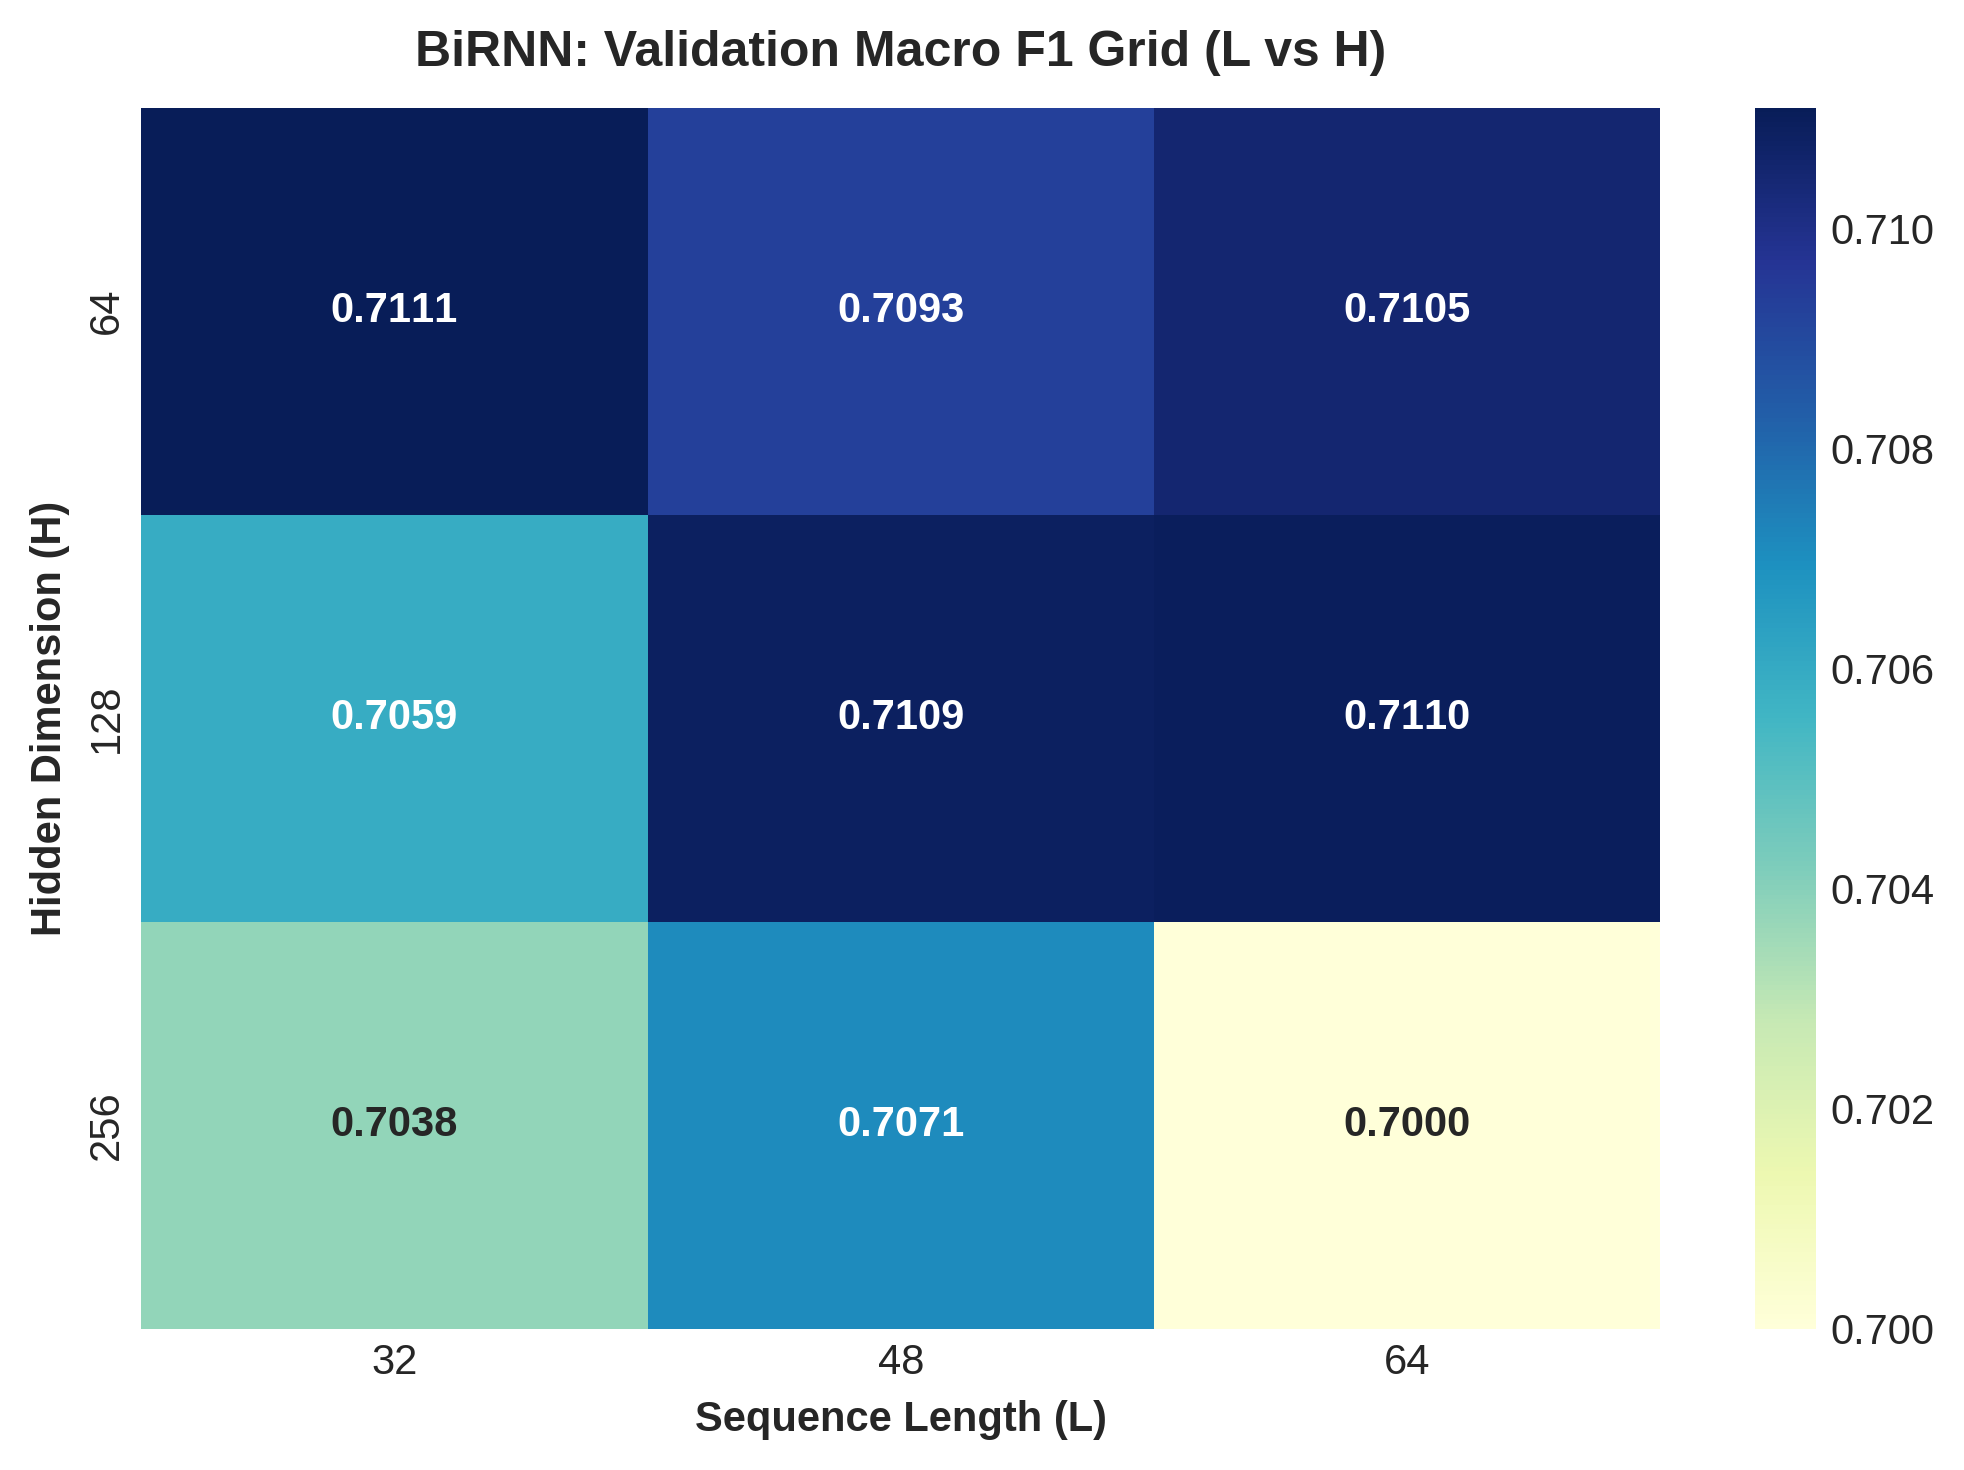


>> Best BiRNN Config: L=32, H=64 (Val Macro F1 = 0.7111)
BiRNN Test Results: Macro F1 = 0.7090 | Accuracy = 0.7406


In [9]:
# ==========================================
# 1. BiRNN (Bidirectional Simple RNN) Tuning
# ==========================================
print("\n" + "="*75)
print("HYPERPARAMETER TUNING: BiRNN (Word2Vec)")
print("Search Space: L in [32, 48, 64] x Hidden Dim H in [64, 128, 256]")
print("="*75)

birnn_results = []
seq_lengths = [32, 48, 64]
hidden_dims = [64, 128, 256]

for L in seq_lengths:
    train_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[L]["train"], y_train), batch_size=64, shuffle=True)
    val_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[L]["val"], y_val), batch_size=128, shuffle=False)
    
    for H in hidden_dims:
        t0 = time.time()
        set_seed(42)
        model = RecurrentClassifier(cell_type='rnn', embed_matrix=BEST_EMBED_MATRIX, hidden_dim=H, num_layers=1, dropout=0.3, num_classes=num_classes)
        _, val_f1, best_ep, _ = train_recurrent_model(model, train_loader, val_loader, max_epochs=6, lr=1e-3, patience=2)
        elapsed = time.time() - t0
        
        print(f"BiRNN | L={L:2d} | H={H:3d} | Val Macro F1: {val_f1:.4f} | Epochs: {best_ep} | Time: {elapsed:.1f}s")
        birnn_results.append({"Seq_Len": L, "Hidden_Dim": H, "Val_Macro_F1": round(val_f1, 4), "Time_Sec": round(elapsed, 1)})

df_birnn_tune = pd.DataFrame(birnn_results)
df_birnn_tune.to_csv(os.path.join(MODEL_DIRS["birnn"], "birnn_tuning_results.csv"), index=False)

pivot_birnn = df_birnn_tune.pivot(index="Hidden_Dim", columns="Seq_Len", values="Val_Macro_F1")
plt.figure(figsize=(7, 5), dpi=300)
sns.heatmap(pivot_birnn, annot=True, fmt=".4f", cmap="YlGnBu", cbar=True, annot_kws={"fontweight": "bold"})
plt.title("BiRNN: Validation Macro F1 Grid (L vs H)", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Sequence Length (L)", fontweight='bold')
plt.ylabel("Hidden Dimension (H)", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIRS["birnn"], "birnn_hyperparam_grid.png"), dpi=300)
plt.show()

best_birnn_cfg = df_birnn_tune.sort_values(by="Val_Macro_F1", ascending=False).iloc[0]
best_L_birnn = int(best_birnn_cfg["Seq_Len"])
best_H_birnn = int(best_birnn_cfg["Hidden_Dim"])
print(f"\n>> Best BiRNN Config: L={best_L_birnn}, H={best_H_birnn} (Val Macro F1 = {best_birnn_cfg['Val_Macro_F1']:.4f})")

train_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_birnn]["train"], y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_birnn]["val"], y_val), batch_size=128, shuffle=False)
test_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_birnn]["test"], y_test), batch_size=128, shuffle=False)

set_seed(42)
best_birnn_model = RecurrentClassifier(cell_type='rnn', embed_matrix=BEST_EMBED_MATRIX, hidden_dim=best_H_birnn, num_layers=1, dropout=0.3, num_classes=num_classes)
best_birnn_model, val_f1, _, birnn_history = train_recurrent_model(best_birnn_model, train_loader, val_loader, max_epochs=8, lr=1e-3, patience=3)
torch.save(best_birnn_model.state_dict(), os.path.join(MODEL_DIRS["birnn"], "best_model.pt"))

birnn_test_metrics = evaluate_model_on_test(best_birnn_model, test_loader, y_test, f"BiRNN (Word2Vec)", MODEL_DIRS["birnn"], history=birnn_history)
birnn_test_metrics["Optimal_Config"] = f"L={best_L_birnn}, H={best_H_birnn}"
print(f"BiRNN Test Results: Macro F1 = {birnn_test_metrics['Macro_F1']:.4f} | Accuracy = {birnn_test_metrics['Accuracy']:.4f}")



HYPERPARAMETER TUNING: BiLSTM (Word2Vec)
Search Space: L in [32, 48, 64] x Hidden Dim H in [64, 128, 256]
BiLSTM | L=32 | H= 64 | Val Macro F1: 0.7030 | Epochs: 2 | Time: 24.4s
BiLSTM | L=32 | H=128 | Val Macro F1: 0.7147 | Epochs: 2 | Time: 28.8s
BiLSTM | L=32 | H=256 | Val Macro F1: 0.7279 | Epochs: 2 | Time: 40.2s
BiLSTM | L=48 | H= 64 | Val Macro F1: 0.7088 | Epochs: 3 | Time: 30.7s
BiLSTM | L=48 | H=128 | Val Macro F1: 0.7241 | Epochs: 3 | Time: 40.8s
BiLSTM | L=48 | H=256 | Val Macro F1: 0.7362 | Epochs: 2 | Time: 51.3s
BiLSTM | L=64 | H= 64 | Val Macro F1: 0.7121 | Epochs: 3 | Time: 31.7s
BiLSTM | L=64 | H=128 | Val Macro F1: 0.7198 | Epochs: 2 | Time: 36.7s
BiLSTM | L=64 | H=256 | Val Macro F1: 0.7324 | Epochs: 2 | Time: 62.7s


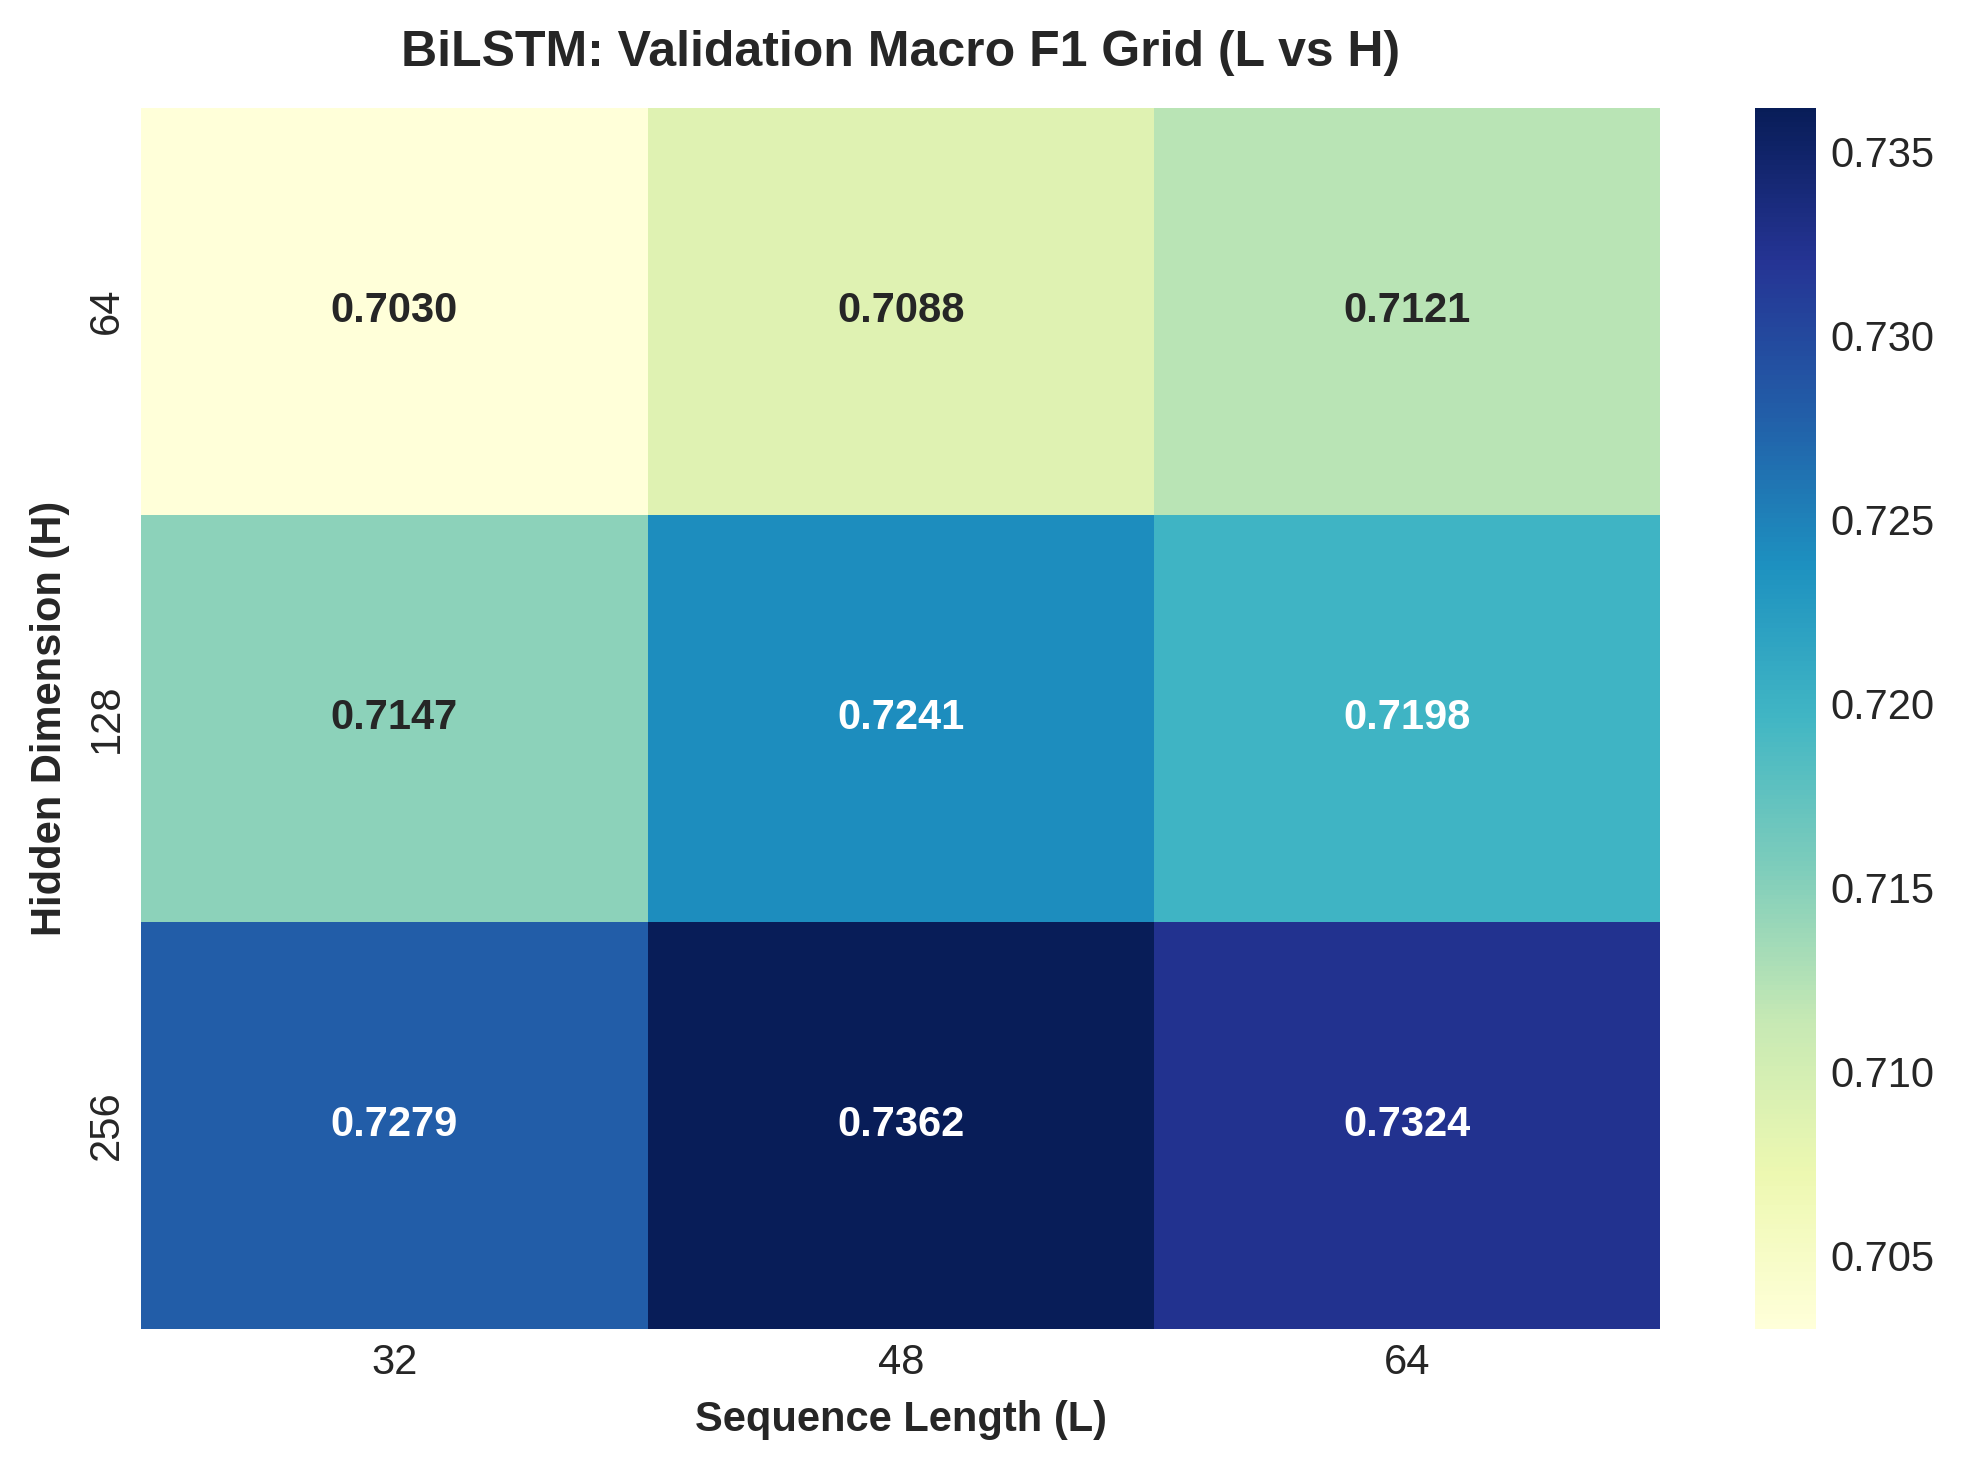


>> Best BiLSTM Config: L=48, H=256 (Val Macro F1 = 0.7362)
BiLSTM Test Results: Macro F1 = 0.7329 | Accuracy = 0.7567


In [10]:
# ==========================================
# 2. BiLSTM (Bidirectional LSTM) Tuning
# ==========================================
print("\n" + "="*75)
print("HYPERPARAMETER TUNING: BiLSTM (Word2Vec)")
print("Search Space: L in [32, 48, 64] x Hidden Dim H in [64, 128, 256]")
print("="*75)

bilstm_results = []

for L in seq_lengths:
    train_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[L]["train"], y_train), batch_size=64, shuffle=True)
    val_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[L]["val"], y_val), batch_size=128, shuffle=False)
    
    for H in hidden_dims:
        t0 = time.time()
        set_seed(42)
        model = RecurrentClassifier(cell_type='lstm', embed_matrix=BEST_EMBED_MATRIX, hidden_dim=H, num_layers=1, dropout=0.3, num_classes=num_classes)
        _, val_f1, best_ep, _ = train_recurrent_model(model, train_loader, val_loader, max_epochs=6, lr=1e-3, patience=2)
        elapsed = time.time() - t0
        
        print(f"BiLSTM | L={L:2d} | H={H:3d} | Val Macro F1: {val_f1:.4f} | Epochs: {best_ep} | Time: {elapsed:.1f}s")
        bilstm_results.append({"Seq_Len": L, "Hidden_Dim": H, "Val_Macro_F1": round(val_f1, 4), "Time_Sec": round(elapsed, 1)})

df_bilstm_tune = pd.DataFrame(bilstm_results)
df_bilstm_tune.to_csv(os.path.join(MODEL_DIRS["bilstm"], "bilstm_tuning_results.csv"), index=False)

pivot_bilstm = df_bilstm_tune.pivot(index="Hidden_Dim", columns="Seq_Len", values="Val_Macro_F1")
plt.figure(figsize=(7, 5), dpi=300)
sns.heatmap(pivot_bilstm, annot=True, fmt=".4f", cmap="YlGnBu", cbar=True, annot_kws={"fontweight": "bold"})
plt.title("BiLSTM: Validation Macro F1 Grid (L vs H)", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Sequence Length (L)", fontweight='bold')
plt.ylabel("Hidden Dimension (H)", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIRS["bilstm"], "bilstm_hyperparam_grid.png"), dpi=300)
plt.show()

best_bilstm_cfg = df_bilstm_tune.sort_values(by="Val_Macro_F1", ascending=False).iloc[0]
best_L_bilstm = int(best_bilstm_cfg["Seq_Len"])
best_H_bilstm = int(best_bilstm_cfg["Hidden_Dim"])
print(f"\n>> Best BiLSTM Config: L={best_L_bilstm}, H={best_H_bilstm} (Val Macro F1 = {best_bilstm_cfg['Val_Macro_F1']:.4f})")

train_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_bilstm]["train"], y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_bilstm]["val"], y_val), batch_size=128, shuffle=False)
test_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_bilstm]["test"], y_test), batch_size=128, shuffle=False)

set_seed(42)
best_bilstm_model = RecurrentClassifier(cell_type='lstm', embed_matrix=BEST_EMBED_MATRIX, hidden_dim=best_H_bilstm, num_layers=1, dropout=0.3, num_classes=num_classes)
best_bilstm_model, val_f1, _, bilstm_history = train_recurrent_model(best_bilstm_model, train_loader, val_loader, max_epochs=8, lr=1e-3, patience=3)
torch.save(best_bilstm_model.state_dict(), os.path.join(MODEL_DIRS["bilstm"], "best_model.pt"))

bilstm_test_metrics = evaluate_model_on_test(best_bilstm_model, test_loader, y_test, f"BiLSTM (Word2Vec)", MODEL_DIRS["bilstm"], history=bilstm_history)
bilstm_test_metrics["Optimal_Config"] = f"L={best_L_bilstm}, H={best_H_bilstm}"
print(f"BiLSTM Test Results: Macro F1 = {bilstm_test_metrics['Macro_F1']:.4f} | Accuracy = {bilstm_test_metrics['Accuracy']:.4f}")



HYPERPARAMETER TUNING: BiGRU (Word2Vec)
Search Space: L in [32, 48, 64] x Hidden Dim H in [64, 128, 256]
BiGRU | L=32 | H= 64 | Val Macro F1: 0.7056 | Epochs: 3 | Time: 29.7s
BiGRU | L=32 | H=128 | Val Macro F1: 0.7145 | Epochs: 3 | Time: 31.6s
BiGRU | L=32 | H=256 | Val Macro F1: 0.7192 | Epochs: 2 | Time: 34.5s
BiGRU | L=48 | H= 64 | Val Macro F1: 0.7165 | Epochs: 3 | Time: 30.0s
BiGRU | L=48 | H=128 | Val Macro F1: 0.7310 | Epochs: 3 | Time: 35.1s
BiGRU | L=48 | H=256 | Val Macro F1: 0.7249 | Epochs: 3 | Time: 53.1s
BiGRU | L=64 | H= 64 | Val Macro F1: 0.7114 | Epochs: 3 | Time: 31.0s
BiGRU | L=64 | H=128 | Val Macro F1: 0.7220 | Epochs: 3 | Time: 38.7s
BiGRU | L=64 | H=256 | Val Macro F1: 0.7236 | Epochs: 2 | Time: 51.1s


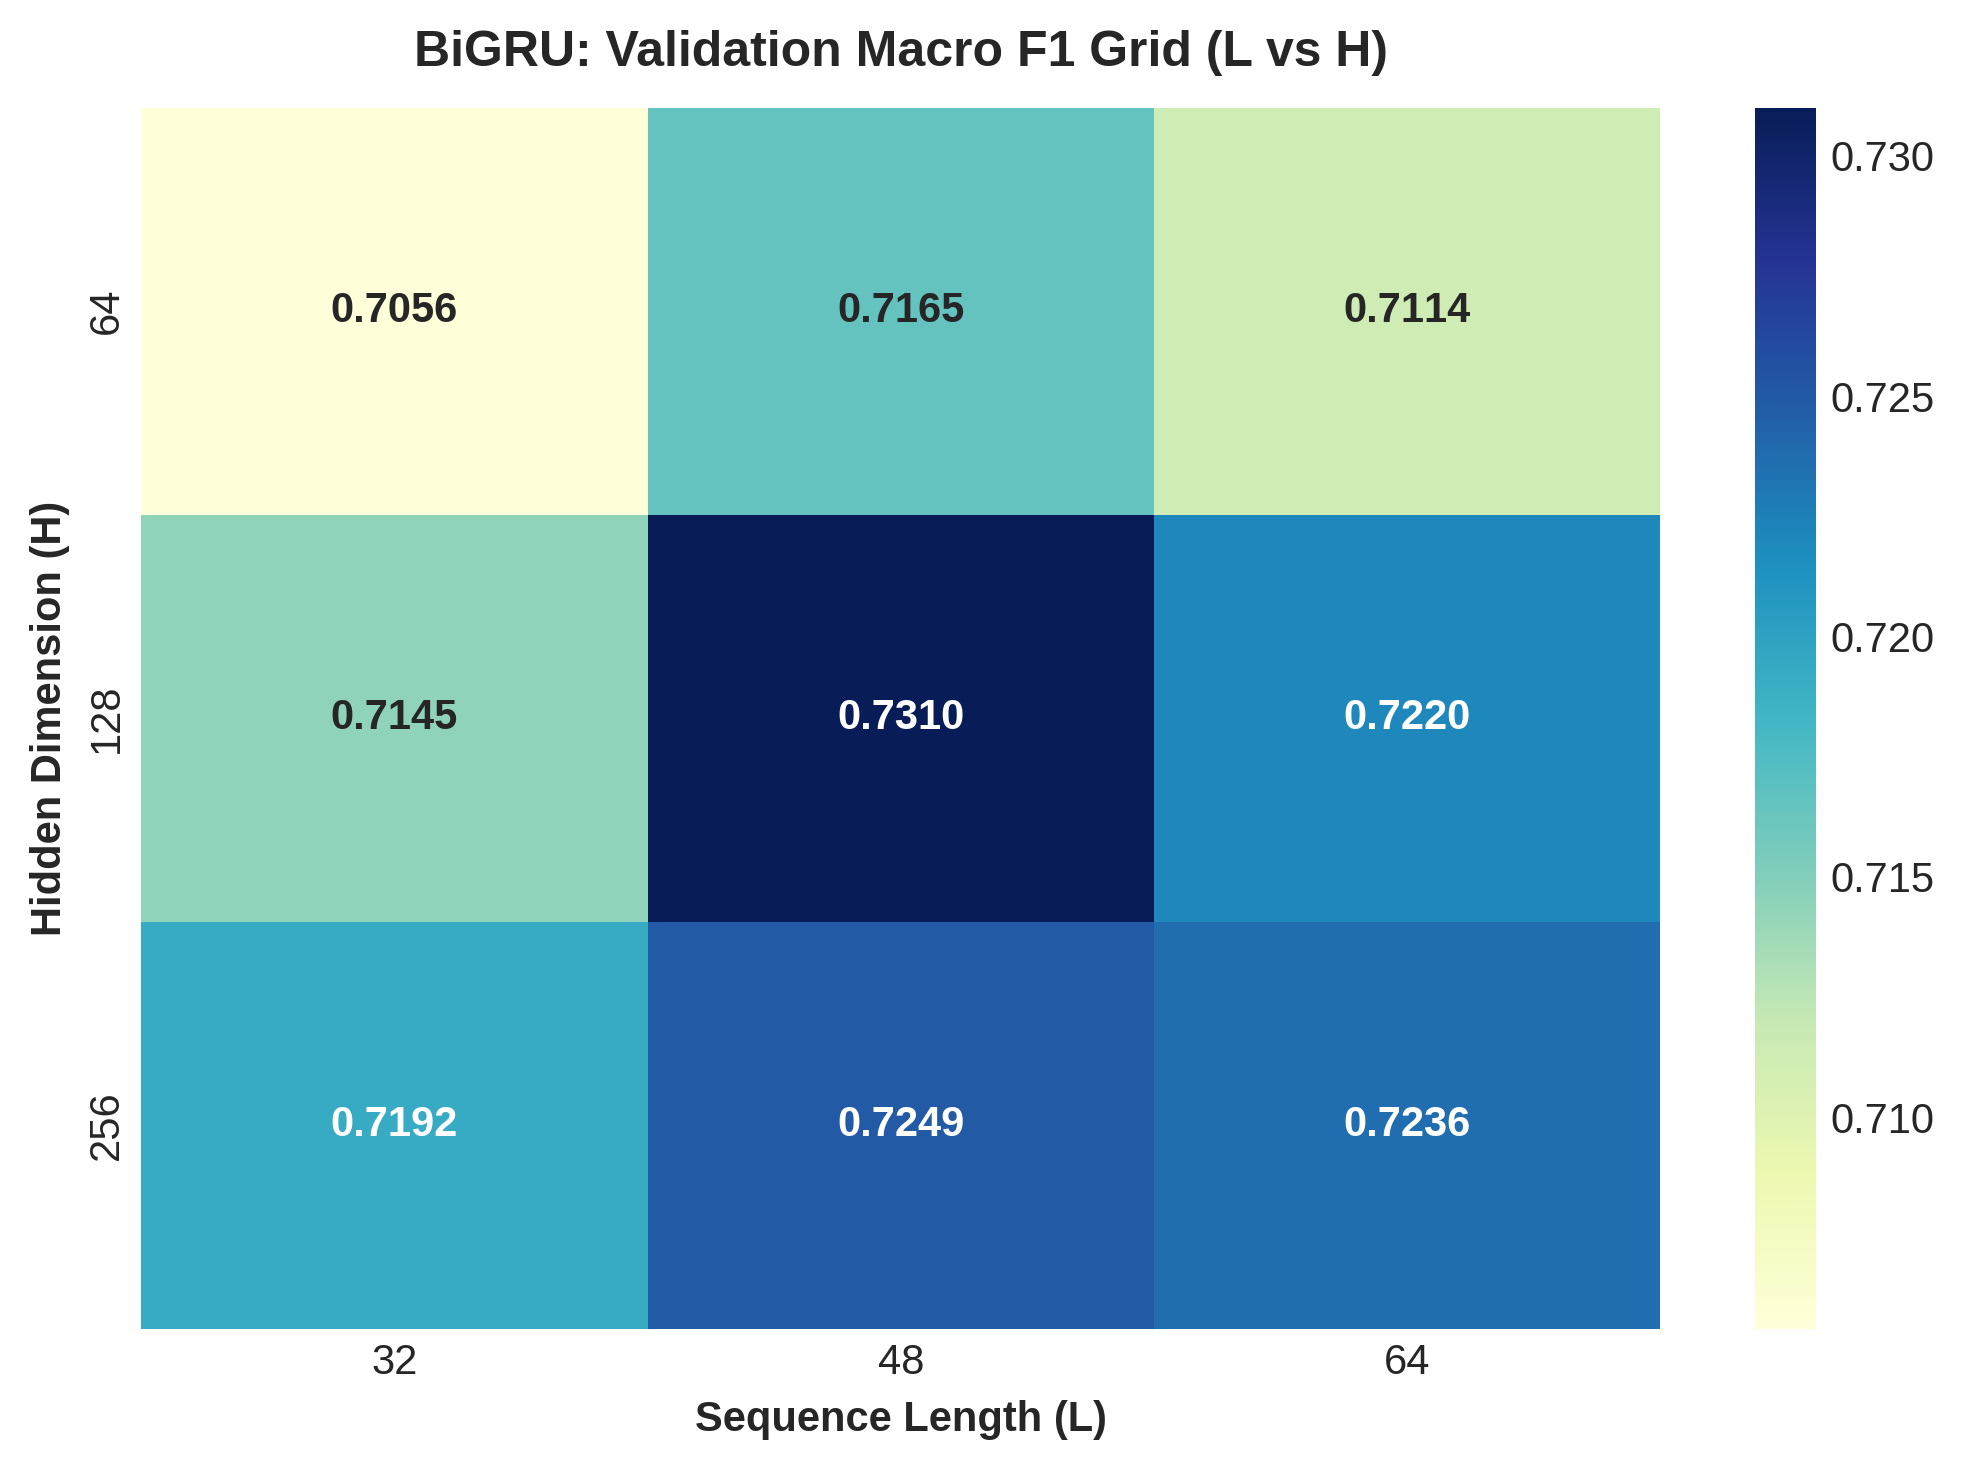


>> Best BiGRU Config: L=48, H=128 (Val Macro F1 = 0.7310)
BiGRU Test Results: Macro F1 = 0.7279 | Accuracy = 0.7516


In [11]:
# ==========================================
# 3. BiGRU (Bidirectional GRU) Tuning
# ==========================================
print("\n" + "="*75)
print("HYPERPARAMETER TUNING: BiGRU (Word2Vec)")
print("Search Space: L in [32, 48, 64] x Hidden Dim H in [64, 128, 256]")
print("="*75)

bigru_results = []
for L in seq_lengths:
    train_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[L]["train"], y_train), batch_size=64, shuffle=True)
    val_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[L]["val"], y_val), batch_size=128, shuffle=False)
    for H in hidden_dims:
        t0 = time.time()
        set_seed(42)
        model = RecurrentClassifier(cell_type='gru', embed_matrix=BEST_EMBED_MATRIX, hidden_dim=H, num_layers=1, dropout=0.3, num_classes=num_classes)
        _, val_f1, best_ep, _ = train_recurrent_model(model, train_loader, val_loader, max_epochs=6, lr=1e-3, patience=2)
        elapsed = time.time() - t0
        print(f"BiGRU | L={L:2d} | H={H:3d} | Val Macro F1: {val_f1:.4f} | Epochs: {best_ep} | Time: {elapsed:.1f}s")
        bigru_results.append({"Seq_Len": L, "Hidden_Dim": H, "Val_Macro_F1": round(val_f1, 4), "Time_Sec": round(elapsed, 1)})

df_bigru_tune = pd.DataFrame(bigru_results)
df_bigru_tune.to_csv(os.path.join(MODEL_DIRS["bigru"], "bigru_tuning_results.csv"), index=False)

pivot_bigru = df_bigru_tune.pivot(index="Hidden_Dim", columns="Seq_Len", values="Val_Macro_F1")
plt.figure(figsize=(7, 5), dpi=300)
sns.heatmap(pivot_bigru, annot=True, fmt=".4f", cmap="YlGnBu", cbar=True, annot_kws={"fontweight": "bold"})
plt.title("BiGRU: Validation Macro F1 Grid (L vs H)", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Sequence Length (L)", fontweight='bold')
plt.ylabel("Hidden Dimension (H)", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIRS["bigru"], "bigru_hyperparam_grid.png"), dpi=300)
plt.show()

best_bigru_cfg = df_bigru_tune.sort_values(by="Val_Macro_F1", ascending=False).iloc[0]
best_L_bigru = int(best_bigru_cfg["Seq_Len"])
best_H_bigru = int(best_bigru_cfg["Hidden_Dim"])
print(f"\n>> Best BiGRU Config: L={best_L_bigru}, H={best_H_bigru} (Val Macro F1 = {best_bigru_cfg['Val_Macro_F1']:.4f})")

train_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_bigru]["train"], y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_bigru]["val"], y_val), batch_size=128, shuffle=False)
test_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_bigru]["test"], y_test), batch_size=128, shuffle=False)

set_seed(42)
best_bigru_model = RecurrentClassifier(cell_type='gru', embed_matrix=BEST_EMBED_MATRIX, hidden_dim=best_H_bigru, num_layers=1, dropout=0.3, num_classes=num_classes)
best_bigru_model, val_f1, _, bigru_history = train_recurrent_model(best_bigru_model, train_loader, val_loader, max_epochs=8, lr=1e-3, patience=3)
torch.save(best_bigru_model.state_dict(), os.path.join(MODEL_DIRS["bigru"], "best_model.pt"))

bigru_test_metrics = evaluate_model_on_test(best_bigru_model, test_loader, y_test, "BiGRU (Word2Vec)", MODEL_DIRS["bigru"], history=bigru_history)
bigru_test_metrics["Optimal_Config"] = f"L={best_L_bigru}, H={best_H_bigru}"
print(f"BiGRU Test Results: Macro F1 = {bigru_test_metrics['Macro_F1']:.4f} | Accuracy = {bigru_test_metrics['Accuracy']:.4f}")



HYPERPARAMETER TUNING: 2-Stacked BiLSTM (num_layers=2)
Inheriting Optimal Parameters from BiLSTM: Sequence Length L*=48, Hidden Dim H*=256
Search Space: Inter-layer & FC Dropout p in [0.2, 0.3, 0.5]
2-Stacked BiLSTM | Dropout=0.2 | Val Macro F1: 0.7283 | Epochs: 2 | Time: 94.7s
2-Stacked BiLSTM | Dropout=0.3 | Val Macro F1: 0.7317 | Epochs: 2 | Time: 94.2s
2-Stacked BiLSTM | Dropout=0.5 | Val Macro F1: 0.7279 | Epochs: 2 | Time: 94.1s


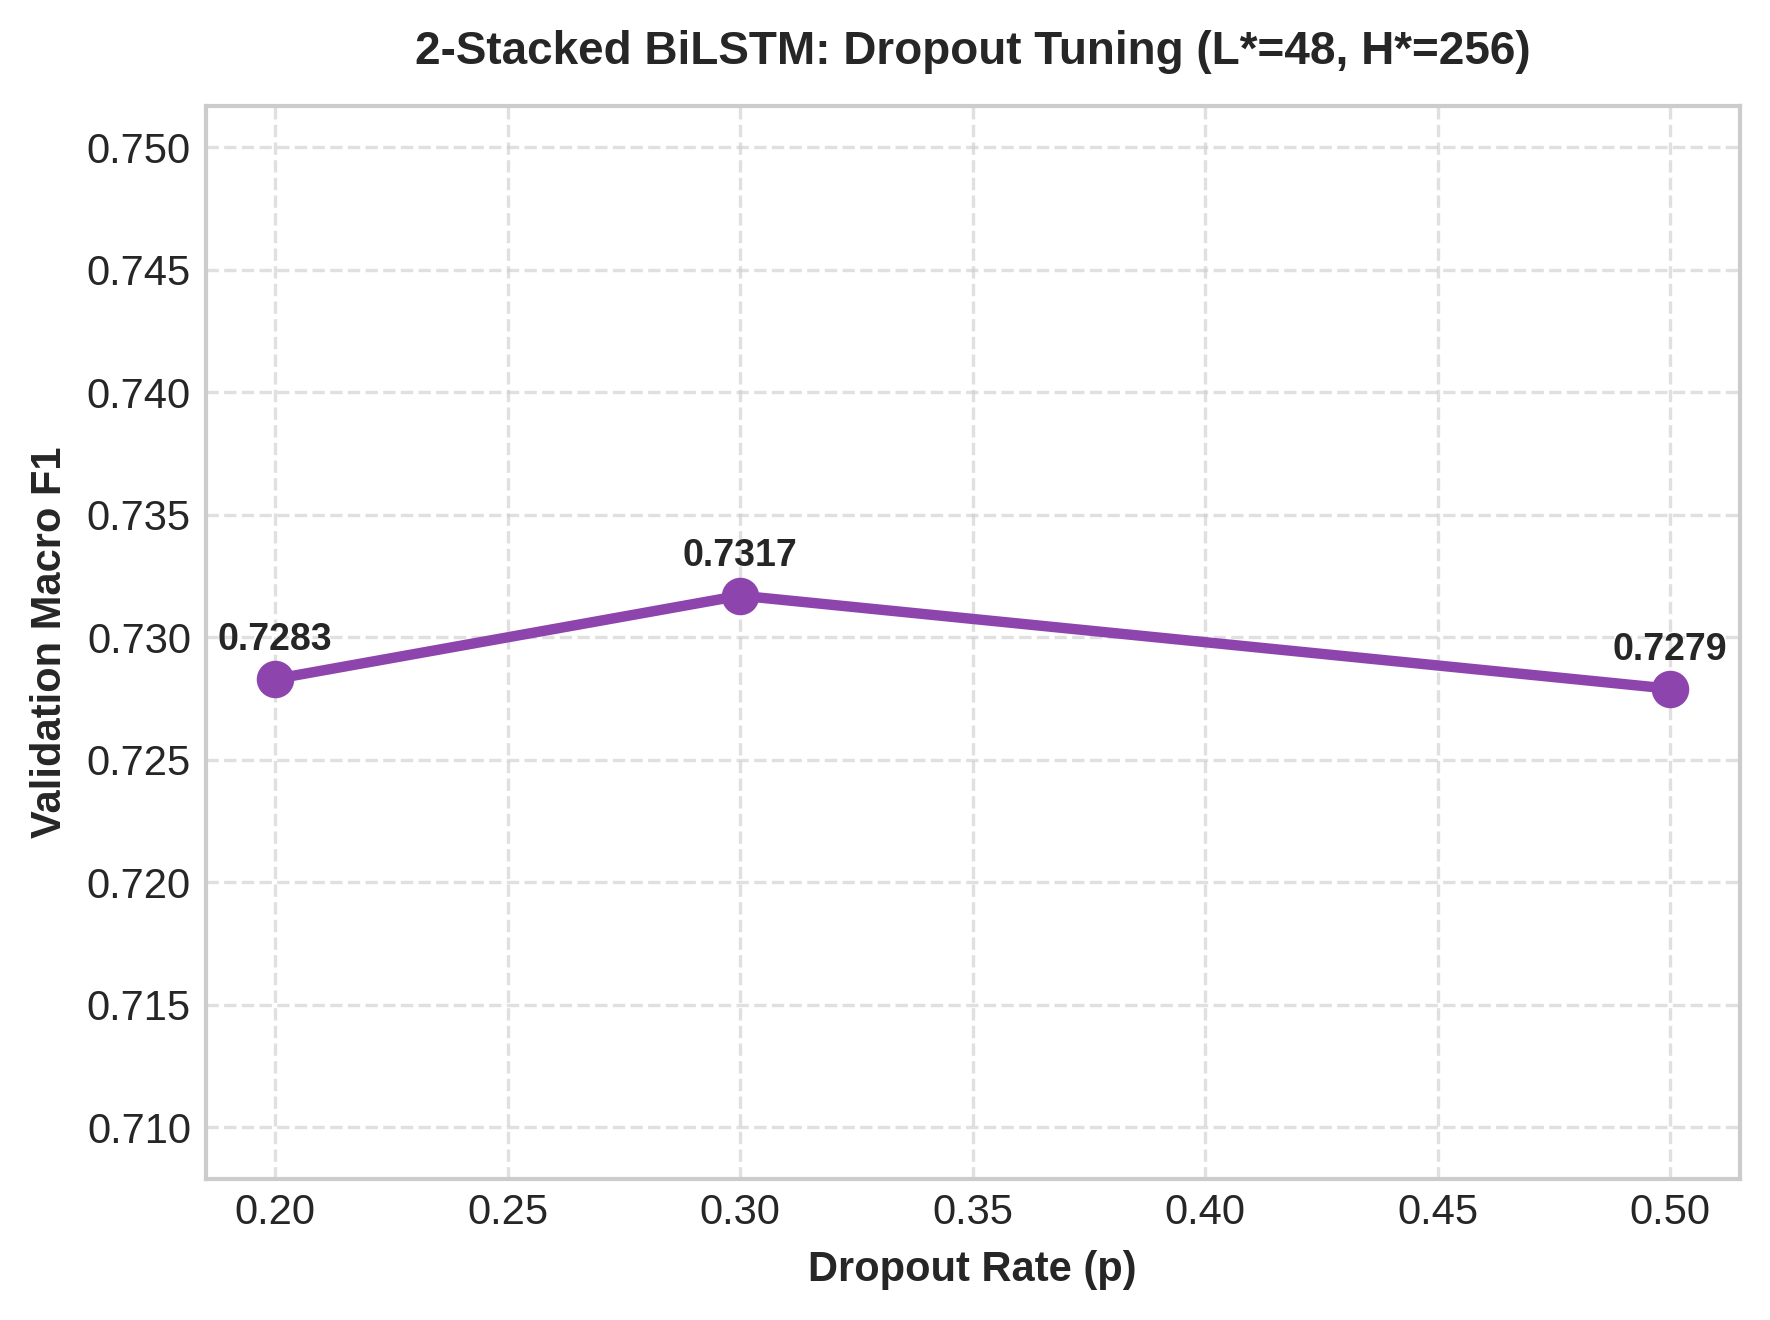


>> Best 2-Stacked BiLSTM Config: Dropout=0.3 (Val Macro F1 = 0.7317)
2-Stacked BiLSTM Test Results: Macro F1 = 0.7369 | Accuracy = 0.7549


In [12]:
# =========================================================================
# 4. 2-Stacked BiLSTM (Inheriting Optimal L* and H* from BiLSTM)
# =========================================================================
print("\n" + "="*75)
print(f"HYPERPARAMETER TUNING: 2-Stacked BiLSTM (num_layers=2)")
print(f"Inheriting Optimal Parameters from BiLSTM: Sequence Length L*={best_L_bilstm}, Hidden Dim H*={best_H_bilstm}")
print(f"Search Space: Inter-layer & FC Dropout p in [0.2, 0.3, 0.5]")
print("="*75)

train_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_bilstm]["train"], y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_bilstm]["val"], y_val), batch_size=128, shuffle=False)
test_loader = DataLoader(TweetSequenceDataset(PRECOMPUTED_DATA[best_L_bilstm]["test"], y_test), batch_size=128, shuffle=False)

stacked_results = []
dropout_candidates = [0.2, 0.3, 0.5]
for drop in dropout_candidates:
    t0 = time.time()
    set_seed(42)
    model = RecurrentClassifier(cell_type='lstm', embed_matrix=BEST_EMBED_MATRIX, hidden_dim=best_H_bilstm, num_layers=2, dropout=drop, num_classes=num_classes)
    _, val_f1, best_ep, _ = train_recurrent_model(model, train_loader, val_loader, max_epochs=6, lr=1e-3, patience=2)
    elapsed = time.time() - t0
    print(f"2-Stacked BiLSTM | Dropout={drop:.1f} | Val Macro F1: {val_f1:.4f} | Epochs: {best_ep} | Time: {elapsed:.1f}s")
    stacked_results.append({"Dropout": drop, "Val_Macro_F1": round(val_f1, 4), "Time_Sec": round(elapsed, 1)})

df_stacked_tune = pd.DataFrame(stacked_results)
df_stacked_tune.to_csv(os.path.join(MODEL_DIRS["stacked_bilstm"], "stacked_bilstm_tuning_results.csv"), index=False)

plt.figure(figsize=(6, 4.5), dpi=300)
plt.plot(df_stacked_tune["Dropout"], df_stacked_tune["Val_Macro_F1"], 'o-', color="#8e44ad", lw=2.5, markersize=8)
for _, r in df_stacked_tune.iterrows():
    plt.annotate(f"{r['Val_Macro_F1']:.4f}", (r['Dropout'], r['Val_Macro_F1']), textcoords="offset points", xytext=(0, 7), ha='center', fontweight='bold', fontsize=9)
plt.title(f"2-Stacked BiLSTM: Dropout Tuning (L*={best_L_bilstm}, H*={best_H_bilstm})", fontsize=11, fontweight='bold', pad=10)
plt.xlabel("Dropout Rate (p)", fontweight='bold')
plt.ylabel("Validation Macro F1", fontweight='bold')
plt.ylim(df_stacked_tune["Val_Macro_F1"].min() - 0.02, df_stacked_tune["Val_Macro_F1"].max() + 0.02)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIRS["stacked_bilstm"], "stacked_bilstm_dropout_tuning.png"), dpi=300)
plt.show()

best_drop = float(df_stacked_tune.sort_values(by="Val_Macro_F1", ascending=False).iloc[0]["Dropout"])
print(f"\n>> Best 2-Stacked BiLSTM Config: Dropout={best_drop} (Val Macro F1 = {df_stacked_tune['Val_Macro_F1'].max():.4f})")

set_seed(42)
best_stacked_model = RecurrentClassifier(cell_type='lstm', embed_matrix=BEST_EMBED_MATRIX, hidden_dim=best_H_bilstm, num_layers=2, dropout=best_drop, num_classes=num_classes)
best_stacked_model, val_f1, _, stacked_history = train_recurrent_model(best_stacked_model, train_loader, val_loader, max_epochs=8, lr=1e-3, patience=3)
torch.save(best_stacked_model.state_dict(), os.path.join(MODEL_DIRS["stacked_bilstm"], "best_model.pt"))

stacked_test_metrics = evaluate_model_on_test(best_stacked_model, test_loader, y_test, "2-Stacked BiLSTM (Word2Vec)", MODEL_DIRS["stacked_bilstm"], history=stacked_history)
stacked_test_metrics["Optimal_Config"] = f"L={best_L_bilstm}, H={best_H_bilstm}, drop={best_drop}"
print(f"2-Stacked BiLSTM Test Results: Macro F1 = {stacked_test_metrics['Macro_F1']:.4f} | Accuracy = {stacked_test_metrics['Accuracy']:.4f}")



FINAL BENCHMARK SUMMARY: Word2Vec + Recurrent Deep Learning Architectures
             Model  Accuracy  Macro_F1  Weighted_F1  Precision  Recall  Latency_ms  Total_Params        Optimal_Config
  2-Stacked BiLSTM    0.7549    0.7369       0.7513     0.7404  0.7364       0.102      12840274 L=48, H=256, drop=0.3
  BiLSTM (1-Layer)    0.7567    0.7329       0.7558     0.7333  0.7375       0.047      11263314           L=48, H=256
   BiGRU (1-Layer)    0.7516    0.7279       0.7494     0.7500  0.7128       0.021      10448210           L=48, H=128
BiRNN (Simple RNN)    0.7406    0.7090       0.7393     0.7360  0.6911       0.009      10163538            L=32, H=64


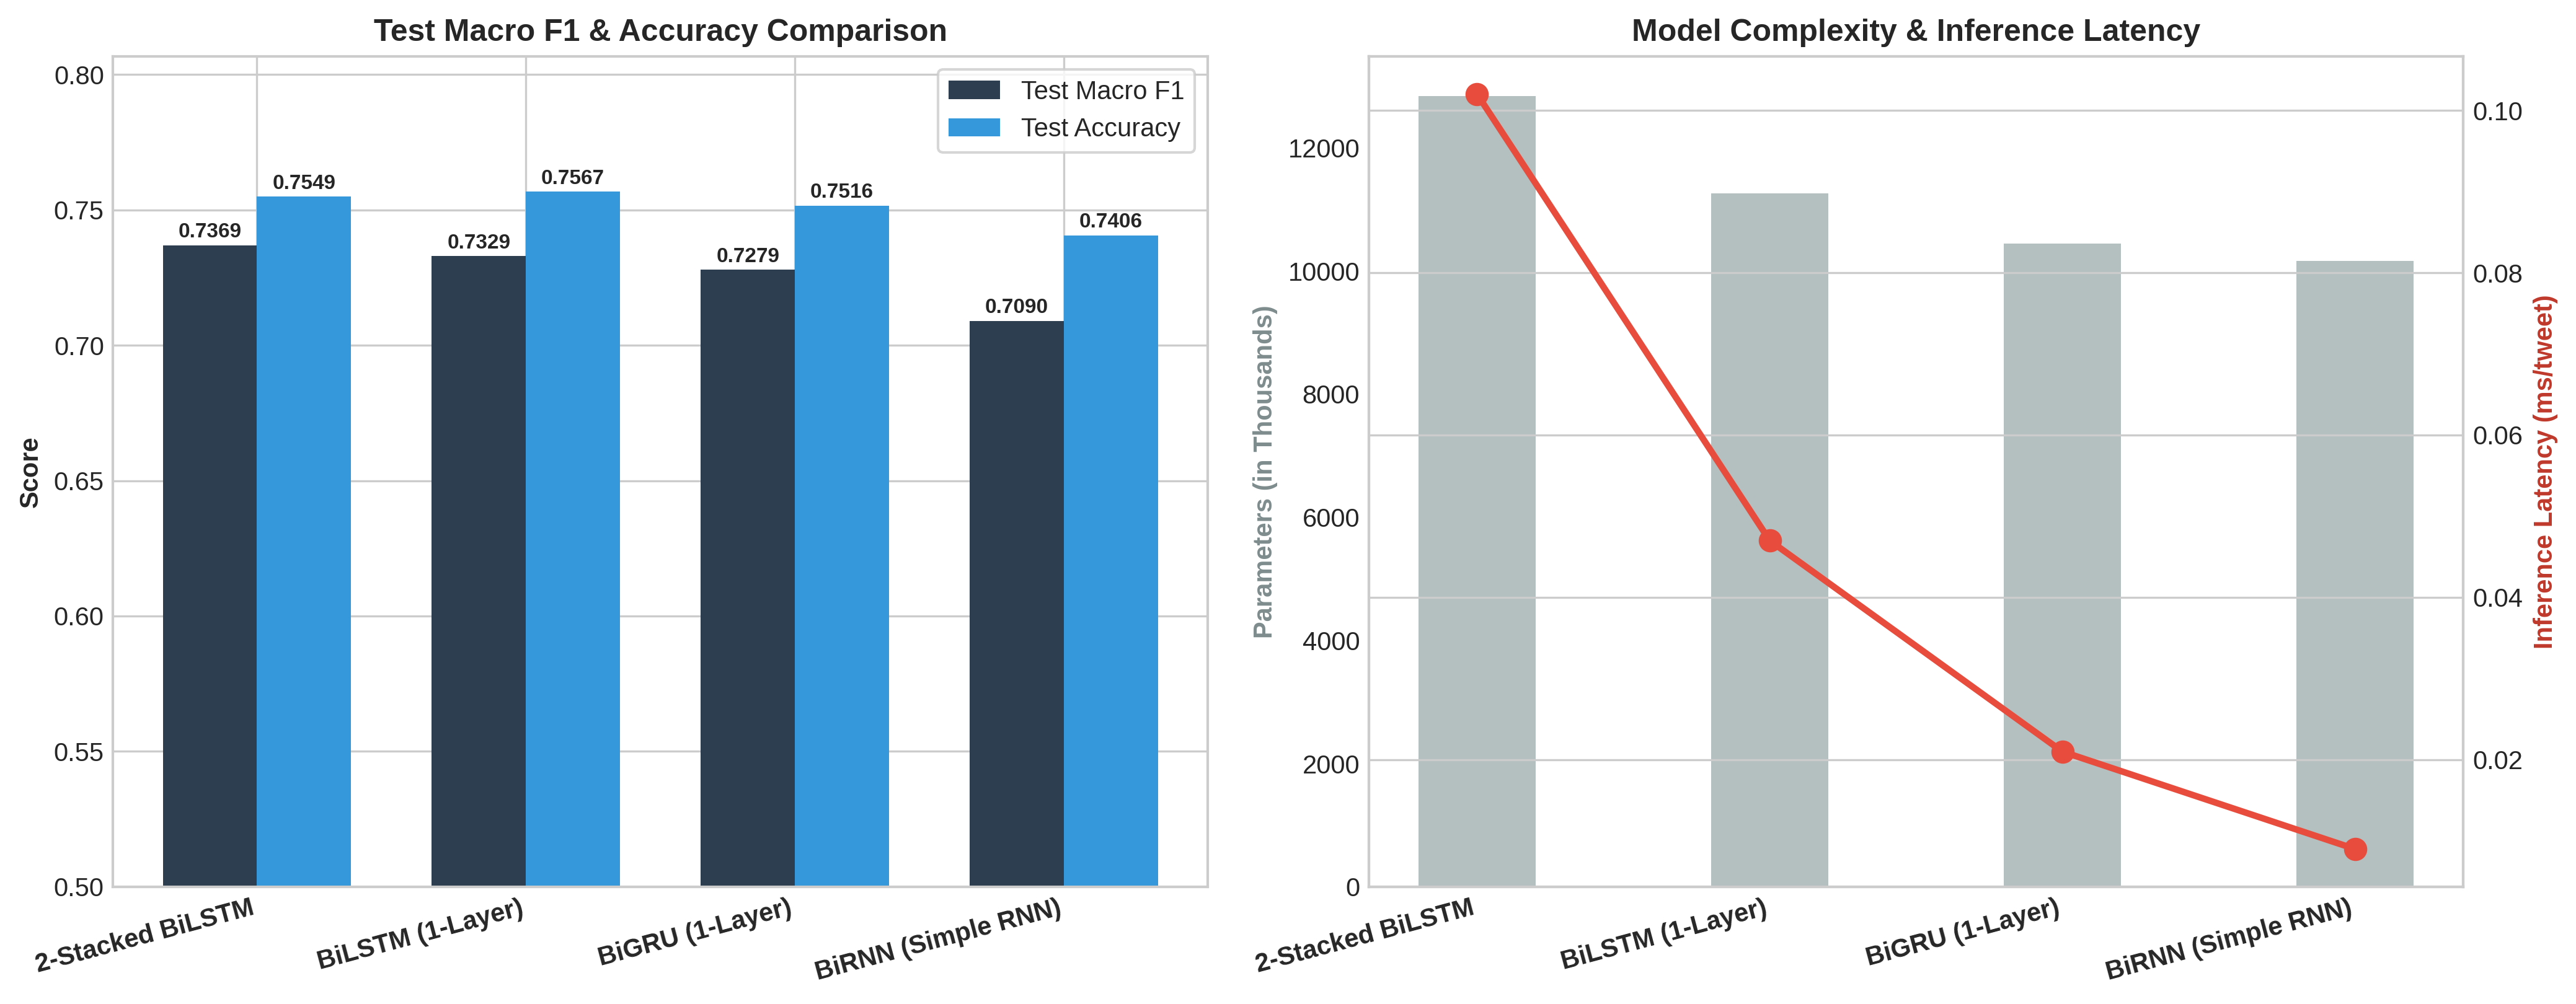

In [13]:
# Benchmark Summary
summary_rows = [
    {"Model": "BiRNN (Simple RNN)", **birnn_test_metrics},
    {"Model": "BiLSTM (1-Layer)", **bilstm_test_metrics},
    {"Model": "BiGRU (1-Layer)", **bigru_test_metrics},
    {"Model": "2-Stacked BiLSTM", **stacked_test_metrics}
]
df_summary = pd.DataFrame(summary_rows).sort_values(by="Macro_F1", ascending=False)
df_summary.to_csv(os.path.join(MODEL_DIRS["summary"], "recurrent_models_benchmark_summary.csv"), index=False)

print("\n" + "="*85)
print("FINAL BENCHMARK SUMMARY: Word2Vec + Recurrent Deep Learning Architectures")
print("="*85)
print(df_summary.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)
models = df_summary["Model"]
x = np.arange(len(models))
w = 0.35

ax1.bar(x - w/2, df_summary["Macro_F1"], w, label="Test Macro F1", color="#2c3e50")
ax1.bar(x + w/2, df_summary["Accuracy"], w, label="Test Accuracy", color="#3498db")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha='right', fontweight='bold')
ax1.set_ylabel("Score", fontweight='bold')
ax1.set_ylim(0.50, max(df_summary["Accuracy"].max(), df_summary["Macro_F1"].max()) + 0.05)
ax1.set_title("Test Macro F1 & Accuracy Comparison", fontsize=12, fontweight='bold')
ax1.legend(frameon=True, facecolor='white')
for i, row in df_summary.reset_index(drop=True).iterrows():
    ax1.annotate(f"{row['Macro_F1']:.4f}", (i - w/2, row['Macro_F1']), textcoords="offset points", xytext=(0, 3), ha='center', fontsize=8, fontweight='bold')
    ax1.annotate(f"{row['Accuracy']:.4f}", (i + w/2, row['Accuracy']), textcoords="offset points", xytext=(0, 3), ha='center', fontsize=8, fontweight='bold')

ax2_twin = ax2.twinx()
p1 = ax2.bar(x, df_summary["Total_Params"] / 1000.0, 0.4, label="Parameters (k)", color="#95a5a6", alpha=0.7)
p2 = ax2_twin.plot(x, df_summary["Latency_ms"], 'o-', color="#e74c3c", lw=2.5, markersize=8, label="Latency (ms/tweet)")
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=15, ha='right', fontweight='bold')
ax2.set_ylabel("Parameters (in Thousands)", fontweight='bold', color="#7f8c8d")
ax2_twin.set_ylabel("Inference Latency (ms/tweet)", fontweight='bold', color="#c0392b")
ax2.set_title("Model Complexity & Inference Latency", fontsize=12, fontweight='bold')
ax2.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIRS["summary"], "recurrent_models_benchmark_plot.png"), dpi=300)
plt.show()


In [14]:
# Package all results into zip file for easy export
import shutil
zip_path = "results_02_word2vec_recurrent_models"
shutil.make_archive(zip_path, 'zip', OUTPUT_BASE)
print(f"\nAll artifacts, models, CSVs, and plots successfully packaged to {zip_path}.zip!")
print(f"Execution complete. Output directory: {OUTPUT_BASE}")



All artifacts, models, CSVs, and plots successfully packaged to results_02_word2vec_recurrent_models.zip!
Execution complete. Output directory: /kaggle/working/results/02_word2vec_recurrent_models
